In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
a = 0.1
b = 0.4
u_star = a + b
v_star = b / ((a+b)**2)
gamma = 1e3

In [3]:
L, N = 1, 50
dx = L / (N - 1)

In [4]:
u = np.full((N,N), u_star)
v = np.full((N,N), v_star)

In [5]:
rng = np.random.default_rng(0)

amp = 0.01
u = u + rng.uniform(-amp, amp, size=u.shape)
v = v + rng.uniform(-amp, amp, size=v.shape)

In [6]:
def schnakenberg_laplacian_2D(x, dx):
    x_pad = np.pad(x, pad_width=1, mode="edge")

    center = x_pad[1:-1, 1:-1]
    up = x_pad[0:-2, 1:-1]
    down = x_pad[2:, 1:-1]
    left = x_pad[1:-1, 0:-2]
    right = x_pad[1:-1, 2:]

    d2 = ((up + down + left + right) - (4 * center)) / (dx**2)
    return d2

In [7]:
test_grid = np.ones((50,50)) * 2

assert np.allclose(schnakenberg_laplacian_2D(test_grid, dx), 0)

In [8]:
dt = 0.001
n_step = 1e6
k = 200
D = 10

In [9]:
def timestep_2D(u, v, dx=dx, dt=((0.2 * dx**2)/(4*D)), 
                n_step=n_step, k=k, gamma=gamma, a=a, b=b, D=D):
    history_u = []
    history_v = []
    for step in range(int(n_step)):
        if step % k == 0:
            history_u.append(u.copy())
            history_v.append(v.copy())

        L_u = schnakenberg_laplacian_2D(u, dx)
        L_v = schnakenberg_laplacian_2D(v, dx)

        f_u = gamma * (a - u + ((u**2)*v))
        g_v = gamma * (b - ((u**2)*v))

        u = u + dt * (L_u + f_u)
        v = v + dt * ((D*L_v) + g_v)

    return np.asarray(history_u), np.asarray(history_v)

In [10]:
hist_u, hist_v = timestep_2D(u,v)

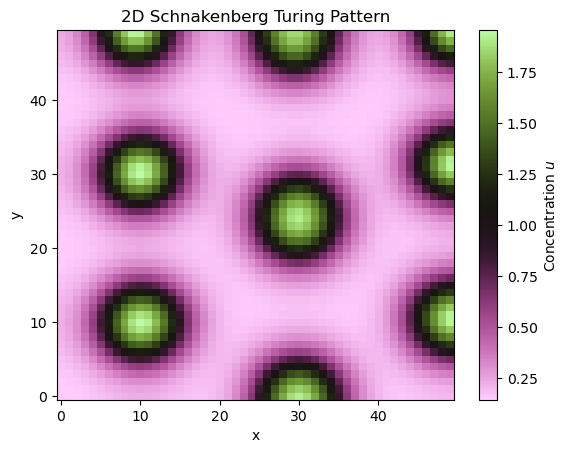

In [11]:
plt.imshow(
    hist_u[-1],
    cmap="vanimo",
    origin="lower",
    aspect='auto',
)
plt.colorbar(label=rf"Concentration $u$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Schnakenberg Turing Pattern")
plt.show()

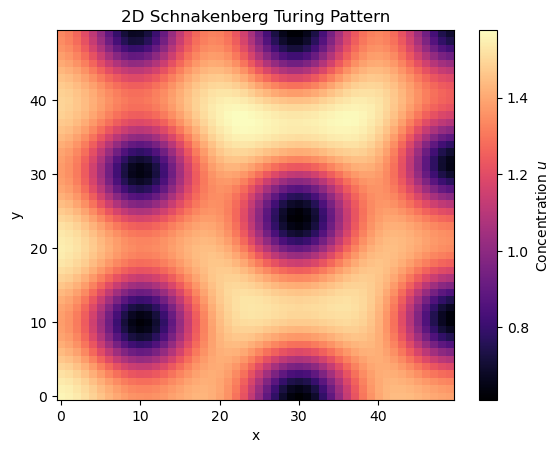

In [12]:
plt.imshow(
    hist_v[-1],
    cmap="magma",
    origin="lower",
    aspect='auto',
)
plt.colorbar(label=rf"Concentration $u$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Schnakenberg Turing Pattern")
plt.show()

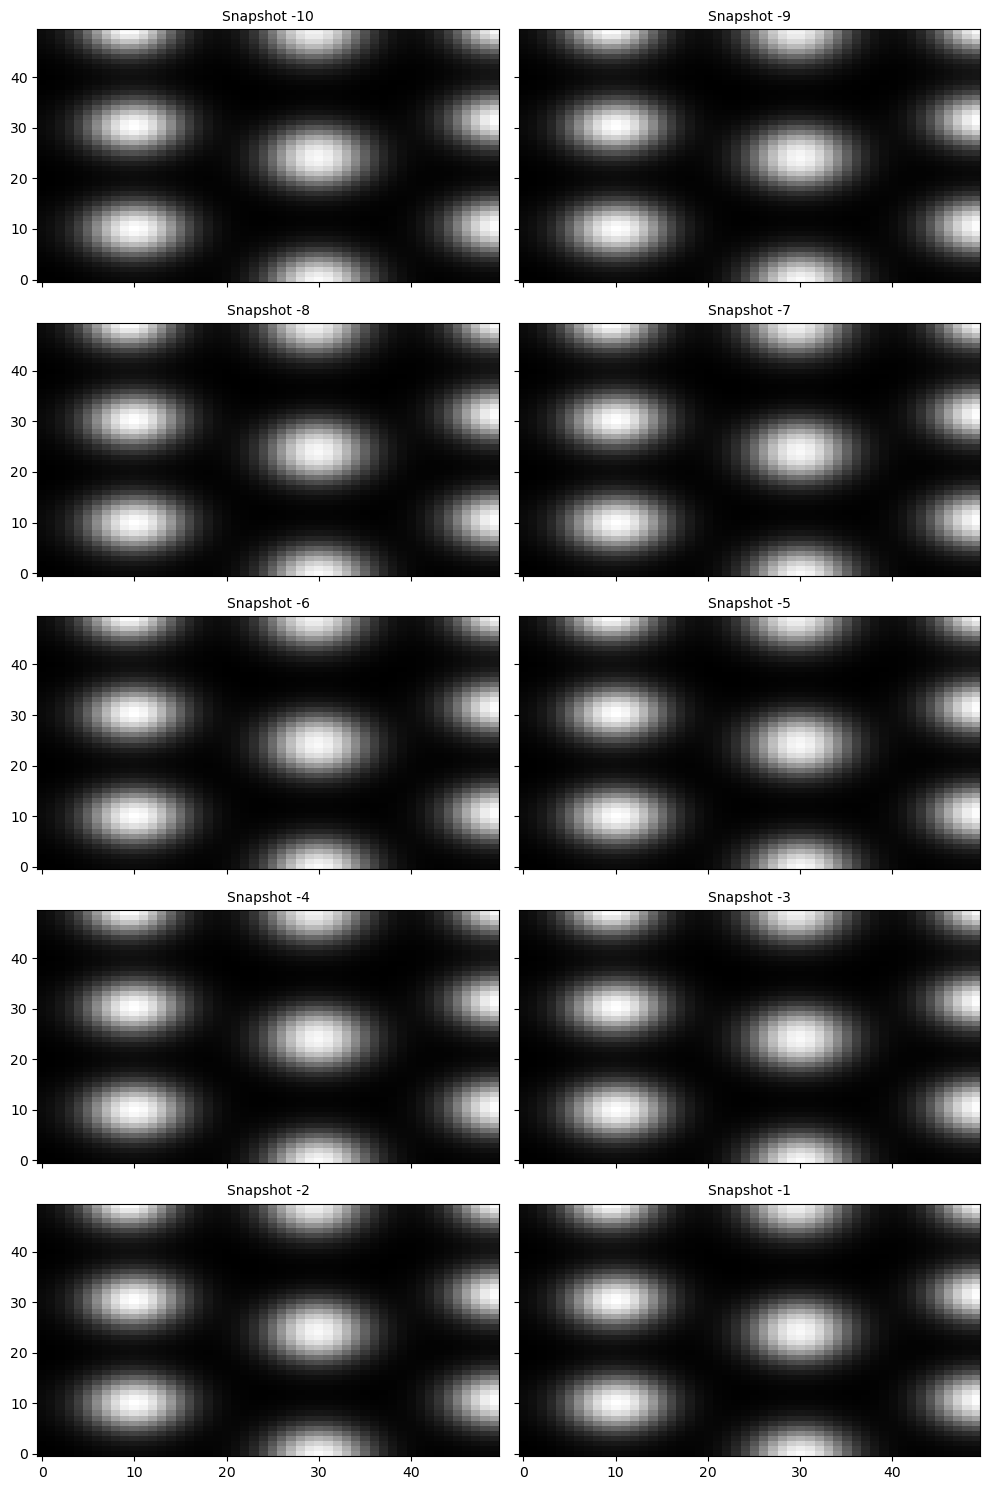

In [15]:
# 1. Create a 5x2 grid of subplots (10 total axes)
fig, axes = plt.subplots(5, 2, figsize=(10, 15), sharex=True, sharey=True)

# 2. Flatten the 2D axes array to iterate linearly (axes.flat has length 10)
# 3. Use step=-1 to count backward through time indices
time_indices = list(range(10, 0, -1))

for idx, (a, step_back) in enumerate(zip(axes.flat, time_indices)):
    # Slice 3D array: hist_u[-step_back] gets the 2D spatial slice
    im = a.imshow(
        hist_u[-step_back],
        cmap="gray",
        origin="lower",
        aspect='auto',
    )
    a.set_title(f"Snapshot -{step_back}", fontsize=10)

fig.tight_layout()
plt.show()